In [1]:
import numpy as np
import pandas as pd
from anndata import AnnData
import scanpy as sc
import multiprocessing as mp
from tqdm import tqdm

Task: map unpaired single-cell multi-omics cells to spatial locations

# load data

In [2]:
import os
import sys
sys.path.insert(1, '/home/nas3/biod/yangchenghui/proj2/UniG_master/src')
import unig as ug
ug.__version__

/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'1.1'

In [ ]:
workdir = '/home/nas3/biod/yangchenghui/proj2/proj2_on_HumanHeart/UniG_result/'
ug.settings.set_workdir(workdir)

# Data preprocessing

In [ ]:
heart_sc_RNA_adata = sc.read_h5ad('/home/nas3/biod/yangchenghui/proj2/proj2_on_HumanHeart/SIMBA_result/heart_sc_RNA_adata_5k.h5ad')
heart_sc_ATAC_adata = sc.read_h5ad('/home/nas3/biod/yangchenghui/proj2/proj2_on_HumanHeart/SIMBA_result/heart_sc_ATAC_adata_5k.h5ad')
heart_st_adata = sc.read_h5ad('/home/nas3/biod/yangchenghui/proj2/Human_heart_data/HumanHeart_spatial_RNA.h5ad')
heart_st_adata.obs['cell_type'] = heart_st_adata.obs['cell_type_original']
heart_sc_RNA_adata, heart_sc_ATAC_adata, heart_st_adata

(AnnData object with n_obs × n_vars = 5000 × 29046
     obs: 'sample', 'nCounts_RNA', 'nFeaturess_RNA', 'percent_mito', 'doublet_score', 'dissociation_score', 'cell_type_original', 'patient_region_id', 'donor_id', 'patient_group', 'major_labl', 'final_cluster', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage'
     var: 'features',
 AnnData object with n_obs × n_vars = 5000 × 522279
     obs: 'nCounts_RNA', 'nFeaturess_RNA', 'sample', 'cell_type_original', 'region', 'donor_id', 'patient_region', 'patient_group', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_et

RNA processing

For RNA data, genes with common names across all samples are first selected to ensure consistent identifiers; low‑expression genes are then filtered out, and the remaining expression matrix is normalized to correct for technical variations.

In [ ]:
genes_all_com = list(set(heart_sc_RNA_adata.var_names).intersection(set(heart_st_adata.var_names)))
len(genes_all_com)
heart_sc_RNA_adata = heart_sc_RNA_adata[:, genes_all_com].copy()
heart_st_adata = heart_st_adata[:, genes_all_com].copy()

heart_sc_RNA_adata = ug.pp.preprocess_rna(heart_sc_RNA_adata)
heart_st_adata = ug.pp.preprocess_rna(heart_st_adata, n_top_genes = 5000)
heart_sc_RNA_adata, heart_st_adata

(AnnData object with n_obs × n_vars = 5000 × 15169
     obs: 'sample', 'nCounts_RNA', 'nFeaturess_RNA', 'percent_mito', 'doublet_score', 'dissociation_score', 'cell_type_original', 'patient_region_id', 'donor_id', 'patient_group', 'major_labl', 'final_cluster', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage'
     var: 'features', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'variable'
     uns: 'log1p', 'hvg',
 AnnData object with n_obs × n_vars = 3771 × 15433
     obs: 'nCounts_RNA', 'nFeaturess_RNA', 'percent.mt', 'Adipocyte', 'Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Lymphoid', 'Mast', 'Myeloid', 'Neuronal', 'P

ATAC processing

For ATAC data, peaks are filtered.

In [ ]:
heart_sc_ATAC_adata = ug.pp.preprocess_atac(heart_sc_ATAC_adata)
peaks_all = list(heart_sc_ATAC_adata.var_names)
heart_sc_ATAC_adata

AnnData object with n_obs × n_vars = 5000 × 522243
    obs: 'nCounts_RNA', 'nFeaturess_RNA', 'sample', 'cell_type_original', 'region', 'donor_id', 'patient_region', 'patient_group', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'nCount_ATAC', 'nFeature_ATAC', 'nCount_GAM', 'nFeature_GAM'
    var: 'features', 'n_cells', 'chr', 'start', 'end'

For each variable gene, select ATAC peaks that fall within the gene body or in its upstream/downstream regions 

In [ ]:
sc_top_genes = heart_sc_RNA_adata.var_names[heart_sc_RNA_adata.var['highly_variable']].tolist()
spatial_top_genes = heart_st_adata.var_names[heart_st_adata.var['spatially_variable']].tolist()
genes_selected = list(set(sc_top_genes).intersection(set(spatial_top_genes)))
len(genes_selected)

673

In [ ]:
gene_info = pd.read_csv('/home/nas3/biod/yangchenghui/nas2_ych/FGOT-master/data/PBMC_data/hg38.promoter.regions.txt', sep = '\t')
gene_info.head()

,chr,starts,ends,genes
1,chr1,12623,12624.0,DDX11L1
2,chr1,30120,30121.0,WASH7P
3,chr1,18186,18187.0,MIR6859.1
4,chr1,18186,18187.0,MIR6859.2
5,chr1,18186,18187.0,MIR6859.3


In [ ]:
filtered_genes, filtered_peaks, gene_peaks = ug.pp.select_gene_peaks_by_genes_location(gene_info, genes_selected, peaks_all)

Preprocessing gene_info:


72337it [00:00, 496362.18it/s]


Search the genes-peaks correspondence based on gene_info and scope:


41399it [02:40, 257.20it/s] 


Search the filtered peaks:


100%|██████████| 643/643 [00:00<00:00, 38202.95it/s]

There are 643 genes that can be identified from the TSS information.
There are 100567 peaks near the upstream and downstream of the above genes.


In [ ]:
heart_scRNA_adata_fltr = heart_sc_RNA_adata[:,filtered_genes]
heart_scATAC_adata_fltr = heart_sc_ATAC_adata[:,filtered_peaks]
heart_st_adata_fltr = heart_st_adata[:,filtered_genes]
heart_st_adata_fltr.obs["cell_type"] = (
    heart_st_adata_fltr.obs["cell_type"]
    .astype(str)
    .replace({"Cycling.cells": "Cycling cells"})
)
heart_st_adata_fltr.obs["cell_type"] = heart_st_adata_fltr.obs["cell_type"].astype("category")

heart_scRNA_adata_fltr.write(workdir + "/heart_scRNA_adata_fltr.h5ad")
heart_scATAC_adata_fltr.write(workdir + "/heart_scATAC_adata_fltr.h5ad")
heart_st_adata_fltr.write(workdir + "/heart_st_adata_fltr.h5ad")

/tmp/ipykernel_421546/57946364.py:4: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  heart_st_adata_fltr.obs["cell_type"] = (
/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/anndata/_core/anndata.py:1175: ImplicitModificationWarning: Trying to modify attribute `.var` of view, initializing view as actual.
  df[key] = c


gene-peak relation

In [ ]:
from scipy import sparse
gene_to_idx = {gene: i for i, gene in enumerate(filtered_genes)}
peak_to_idx = {peak: i for i, peak in enumerate(filtered_peaks)}
rows = []
cols = []

filtered_peaks_set = set(filtered_peaks)
for gene in tqdm(filtered_genes):
    if gene in gene_peaks:
        current_peaks = gene_peaks[gene]
        valid_peaks = [p for p in current_peaks if p in peak_to_idx]
        if valid_peaks:
            g_idx = gene_to_idx[gene]
            p_idxs = [peak_to_idx[p] for p in valid_peaks]
            rows.extend([g_idx] * len(p_idxs))
            cols.extend(p_idxs)
data = np.ones(len(rows), dtype=int)
sparse_mat = sparse.coo_matrix((data, (rows, cols)), 
                               shape=(len(filtered_genes), len(filtered_peaks))).tocsr()
adata_GP = sc.AnnData(X=sparse_mat)
adata_GP.obs_names = filtered_genes
adata_GP.var_names = filtered_peaks
adata_GP.write(workdir+"adata_GenePeak_final.h5ad")
adata_GP

100%|██████████| 643/643 [00:00<00:00, 6983.97it/s]


AnnData object with n_obs × n_vars = 643 × 100567

gene expression discretization

/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()


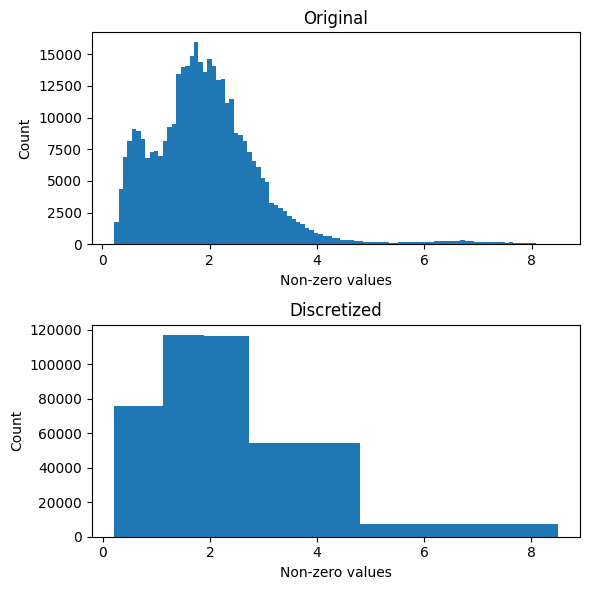

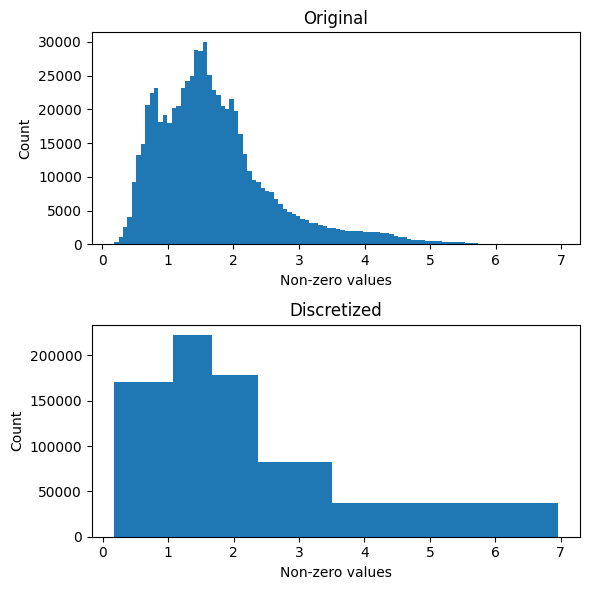

In [ ]:
ug.tl.discretize(heart_scRNA_adata_fltr,n_bins=5)
ug.pl.discretize(heart_scRNA_adata_fltr,kde=False)

ug.tl.discretize(heart_st_adata_fltr,n_bins=5)
ug.pl.discretize(heart_st_adata_fltr,kde=False)

In [ ]:
heart_scRNA_adata_fltr.write(workdir + "heart_RNA_adata_fltr_final.h5ad")
heart_st_adata_fltr.write(workdir + "heart_st_adata_fltr_final.h5ad")

peak accessibility binarization

In [ ]:
ug.pp.binarize(heart_scATAC_adata_fltr)
heart_scATAC_adata_fltr.write(workdir+"/heart_ATAC_adata_fltr_final.h5ad")

peak-motif relation

In [ ]:
# Pure Python peak x motif scanning with defaults matching the motifmatchr workflow.
# Register the FASTA once per Python process; later scans only need peaks and genome.
ug.pp.register_genome(
    "hg38",
    ("/home/nas3/biod/yangchenghui/proj2/UniG_master/genomes/hg38/hg38.fa"),
)
peak_motif_matrix = ug.pp.peak_motif_matrix(
    heart_scATAC_adata_fltr.var_names,
    genome="hg38",
    n_jobs=min(8, mp.cpu_count()),
)

adata_PM = AnnData(peak_motif_matrix)
ug.pp.binarize(adata_PM)

adata_PM.write(workdir+"adata_PeakMotif_final.h5ad")
adata_PM

AnnData object with n_obs × n_vars = 100567 × 633

spatial spot-spot relation

In [ ]:
adata_C_spatial = ug.tl.SpaNeighbor(heart_st_adata_fltr, k = 10)
adata_C_spatial.write(workdir+"spatial_InnerCell_final.h5ad")
adata_C_spatial

AnnData object with n_obs × n_vars = 3771 × 3771

anchor spot-spot relation

#shared features: 643
Performing randomized SVD ...
Searching for mutual nearest neighbors ...
39808 edges are selected
#selected edges: 39808


AnnData object with n_obs × n_vars = 5000 × 3771
    obs: 'sample', 'nCounts_RNA', 'nFeaturess_RNA', 'percent_mito', 'doublet_score', 'dissociation_score', 'cell_type_original', 'patient_region_id', 'donor_id', 'patient_group', 'major_labl', 'final_cluster', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage'
    var: 'nCounts_RNA', 'nFeaturess_RNA', 'percent.mt', 'Adipocyte', 'Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Lymphoid', 'Mast', 'Myeloid', 'Neuronal', 'Pericyte', 'Cycling.cells', 'vSMCs', 'cell_type_original', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_re

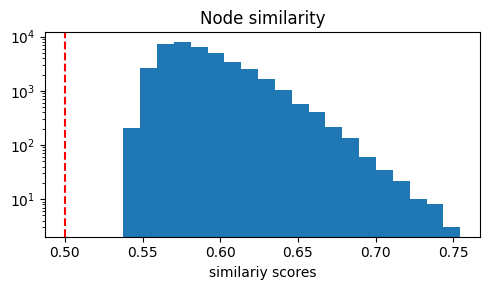

In [ ]:
# MNN between scRNA cells and spatial RNA spots
adata_STscRNA = ug.tl.infer_edges(heart_scRNA_adata_fltr, heart_st_adata_fltr, feature='variable', n_components=15, k=15)
ug.pl.node_similarity(adata_STscRNA,cutoff=0.5)
adata_STscRNA

Gene scores are being calculated for the first time
`use_precomputed` has been ignored
Processing: 0.0%
Processing: 20.0%
#shared features: 643
Performing randomized SVD ...
Searching for mutual nearest neighbors ...
42062 edges are selected
#selected edges: 42062


AnnData object with n_obs × n_vars = 5000 × 5000
    obs: 'sample', 'nCounts_RNA', 'nFeaturess_RNA', 'percent_mito', 'doublet_score', 'dissociation_score', 'cell_type_original', 'patient_region_id', 'donor_id', 'patient_group', 'major_labl', 'final_cluster', 'assay_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'cell_type_ontology_term_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage'
    var: 'nCounts_RNA', 'nFeaturess_RNA', 'sample', 'cell_type_original', 'region', 'donor_id', 'patient_region', 'patient_group', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'se

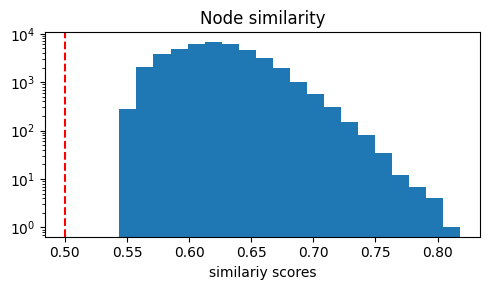

In [ ]:
# MNN between scATAC cells and scRNA cells
sc_GA = ug.tl.gene_scores(heart_scATAC_adata_fltr, genome='hg38',use_gene_weight=True, use_top_pcs=False)
sc.pp.normalize_total(sc_GA)
sc.pp.log1p(sc_GA)

adata_scRNAscATAC = ug.tl.infer_edges(heart_scRNA_adata_fltr, sc_GA, feature = None, n_components=15, k=15)
ug.pl.node_similarity(adata_scRNAscATAC,cutoff=0.5)
adata_scRNAscATAC

#shared features: 643
Performing randomized SVD ...
Searching for mutual nearest neighbors ...
43178 edges are selected
#selected edges: 43178


AnnData object with n_obs × n_vars = 3771 × 5000
    obs: 'nCounts_RNA', 'nFeaturess_RNA', 'percent.mt', 'Adipocyte', 'Cardiomyocyte', 'Endothelial', 'Fibroblast', 'Lymphoid', 'Mast', 'Myeloid', 'Neuronal', 'Pericyte', 'Cycling.cells', 'vSMCs', 'cell_type_original', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_ontology_term_id', 'sex_ontology_term_id', 'tissue_ontology_term_id', 'donor_id', 'suspension_type', 'cell_type', 'assay', 'disease', 'organism', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage'
    var: 'nCounts_RNA', 'nFeaturess_RNA', 'sample', 'cell_type_original', 'region', 'donor_id', 'patient_region', 'patient_group', 'assay_ontology_term_id', 'cell_type_ontology_term_id', 'development_stage_ontology_term_id', 'disease_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'is_primary_data', 'organism_on

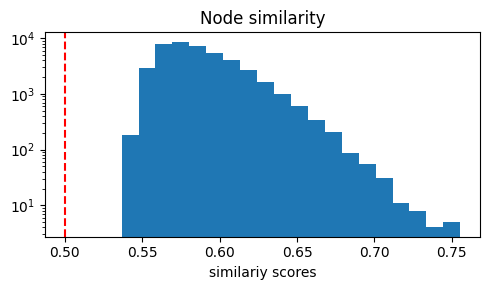

In [ ]:
# MNN between scATAC cells and spatial RNA spots
adata_STscATAC = ug.tl.infer_edges(heart_st_adata_fltr, sc_GA, feature = None, n_components=15, k=15)
ug.pl.node_similarity(adata_STscATAC,cutoff=0.5)
adata_STscATAC

In [ ]:
adata_STscRNA.write(workdir+"/adata_STscRNA_final.h5ad")
adata_scRNAscATAC.write(workdir+"/adata_scRNAscATAC_final.h5ad")
adata_STscATAC.write(workdir+"/adata_STscATAC_final.h5ad")

add Gene activitity

/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/utils.py:70: ImplicitModificationWarning: Setting element `.layers['unig']` of view, initializing view as actual.
  adata.layers['unig'] = X.copy()


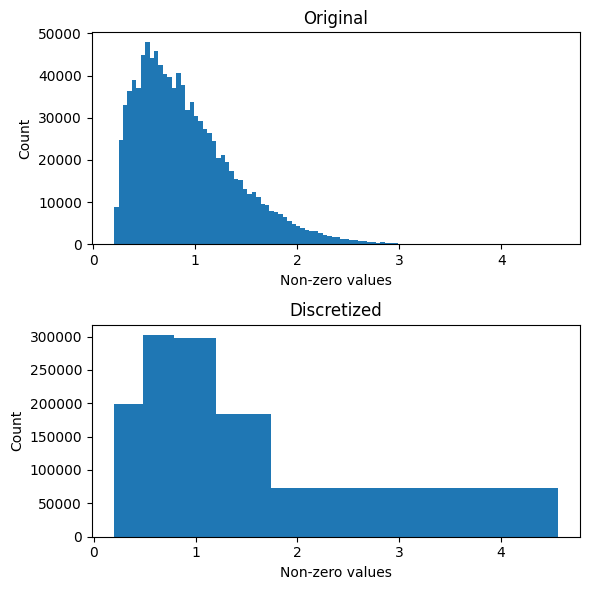

In [ ]:
# add Gene activitity
sc_GA = sc_GA[:, heart_scRNA_adata_fltr.var_names]
ug.tl.discretize(sc_GA,n_bins=5)
ug.pl.discretize(sc_GA,kde=False)
sc_GA.write(workdir+"/adata_sc_GA_final.h5ad")

# Generate graph

In [ ]:
heart_scRNA_adata_fltr = sc.read_h5ad(workdir+"/heart_RNA_adata_fltr_final.h5ad")
heart_scATAC_adata_fltr = sc.read_h5ad(workdir+"/heart_ATAC_adata_fltr_final.h5ad")
heart_st_adata_fltr= sc.read_h5ad(workdir+"/heart_st_adata_fltr_final.h5ad")

adata_PM= sc.read_h5ad(workdir+"/adata_PeakMotif_final.h5ad")
adata_GP= sc.read_h5ad(workdir+"/adata_GenePeak_final.h5ad")
adata_C_spatial= sc.read_h5ad(workdir+"/spatial_InnerCell_final.h5ad")
adata_STscRNA= sc.read_h5ad(workdir+"/adata_STscRNA_final.h5ad")
adata_scRNAscATAC= sc.read_h5ad(workdir+"/adata_scRNAscATAC_final.h5ad")
adata_STscATAC= sc.read_h5ad(workdir+"/adata_STscATAC_final.h5ad")
sc_GA= sc.read_h5ad(workdir+"/adata_sc_GA_final.h5ad")

/tmp/ipykernel_421546/952951824.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(heart_st_adata_fltr, img_key=None, color=["cell_type"],spot_size = 0.014)


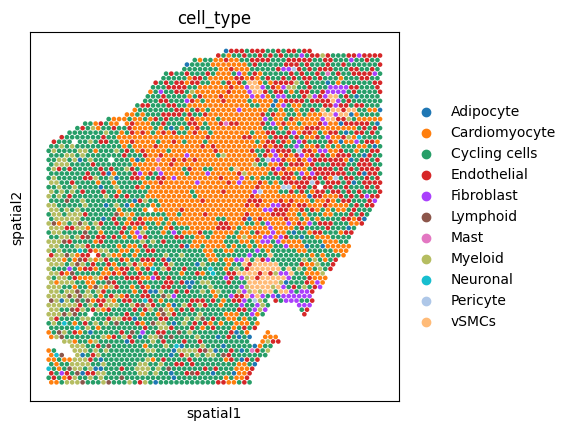

In [ ]:
sc.pl.spatial(heart_st_adata_fltr, img_key=None, color=["cell_type"],spot_size = 0.014)

In [ ]:
ug.gen_graph(list_CP=[heart_scATAC_adata_fltr],
             list_CG=[heart_scRNA_adata_fltr, heart_st_adata_fltr, sc_GA],
             list_PM=[adata_PM],
             list_CC_Spatial=[adata_C_spatial],
             list_CC_Anchor=[adata_STscRNA,adata_scRNAscATAC,adata_STscATAC],
             list_GP=[adata_GP],
             weight_CP = 3,
             weight_PM = 1,
             weight_CC_Spatial = 5,
             weight_CC_Anchor = 5,
             weight_GP = 1,
             copy=False,
             dirname='graph_0')

`unig` does not exist in anndata 0 in `list_CP`.`.X` is being used instead.
relation0: source: C3, destination: P
#edges: 13539602


/home/nas3/biod/yangchenghui/proj2/UniG_master/src/unig/pbg.py:305: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_edges = pd.concat(


`unig` does not exist in anndata 0 in `list_PM`.`.X` is being used instead.
relation1: source: P, destination: M
#edges: 4029957
relation2: source: C, destination: G
#edges: 75775
relation3: source: C, destination: G
#edges: 116961
relation4: source: C, destination: G
#edges: 116180
relation5: source: C, destination: G
#edges: 54071
relation6: source: C, destination: G
#edges: 7115
relation7: source: C2, destination: G
#edges: 170935
relation8: source: C2, destination: G
#edges: 222595
relation9: source: C2, destination: G
#edges: 178670
relation10: source: C2, destination: G
#edges: 82304
relation11: source: C2, destination: G
#edges: 37094
relation12: source: C3, destination: G
#edges: 198945
relation13: source: C3, destination: G
#edges: 302405
relation14: source: C3, destination: G
#edges: 297943
relation15: source: C3, destination: G
#edges: 184042
relation16: source: C3, destination: G
#edges: 73431
`unig` does not exist in anndata 0 in `list_CC_Spatial`.`.X` is being used instea

# Training

In [ ]:
pbg_training_stages = [
    {
        "name": "stage1_pretrain",
        "output": "model_0",
        "params": {
            "workers": 12,
            "lr": 0.1,
            "num_epochs": 10,
        },
    },
    {
        "name": "stage2_joint_finetune",
        "resume_from_previous": True,
        "params": {
            "workers": 12,
            "lr": 0.01,
            "num_epochs": 20,
            "alpha_ot_rna": 1e4,
            "alpha_ot_atac": 2e4,
            "alpha_triplet": 1000,
            "alpha_ot_gp": 2000,
            "begin_triplet_epoch": 10,
            "triplet_update_freq": 2,
        },
    },
]

pbg_configs = ug.run_training_stages(
    base_params=ug.settings.pbg_params,
    stages=pbg_training_stages,
)

=============== Start stage1_pretrain ===============
Random seeds set to 42 for reproducibility
Auto-estimated weight decay: 1.774075E-03
Training mode: standard
Converting input data...
[2026-08-29 16:05:49.502182] Using the 22 relation types given in the config
[2026-08-29 16:05:49.502815] Searching for the entities in the edge files...
[2026-08-29 16:06:13.450841] Entity type C:
[2026-08-29 16:06:13.452023] - Found 5000 entities
[2026-08-29 16:06:13.452350] - Removing the ones with fewer than 1 occurrences...
[2026-08-29 16:06:13.453096] - Left with 5000 entities
[2026-08-29 16:06:13.453334] - Shuffling them...
[2026-08-29 16:06:13.455197] Entity type C2:
[2026-08-29 16:06:13.455769] - Found 3771 entities
[2026-08-29 16:06:13.456016] - Removing the ones with fewer than 1 occurrences...
[2026-08-29 16:06:13.456570] - Left with 3771 entities
[2026-08-29 16:06:13.456806] - Shuffling them...
[2026-08-29 16:06:13.458181] Entity type C3:
[2026-08-29 16:06:13.458431] - Found 5000 entities

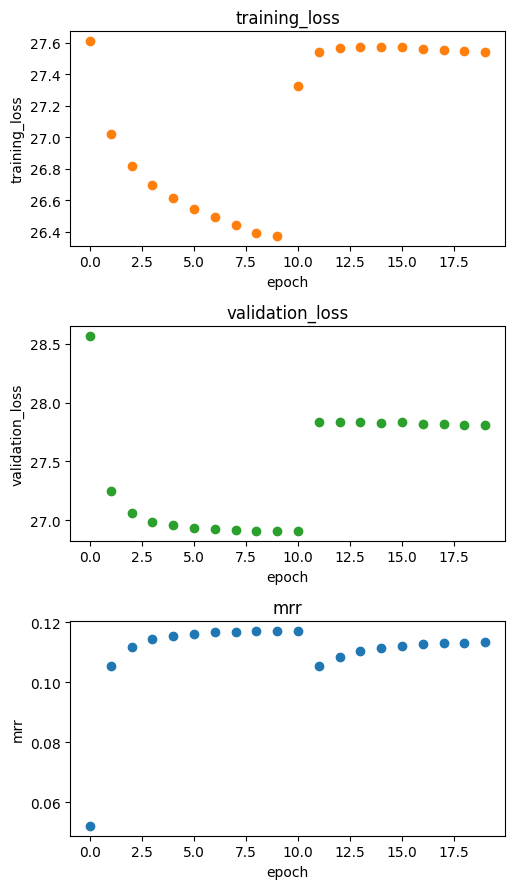

In [ ]:
dict_config_s2 = pbg_configs["stage2_joint_finetune"]
ug.settings.pbg_params = dict_config_s2
ug.pl.pbg_metrics(fig_ncol=1)

# Post-training analysis

In [ ]:
dict_adata = ug.tl.read_embedding()
dict_adata

{'G': AnnData object with n_obs × n_vars = 643 × 50,
 'P': AnnData object with n_obs × n_vars = 100567 × 50,
 'C': AnnData object with n_obs × n_vars = 5000 × 50,
 'M': AnnData object with n_obs × n_vars = 633 × 50,
 'C3': AnnData object with n_obs × n_vars = 5000 × 50,
 'C2': AnnData object with n_obs × n_vars = 3771 × 50}

In [ ]:
adata_C = dict_adata['C']
adata_C2 = dict_adata['C2']
adata_C3 = dict_adata['C3']
adata_G = dict_adata['G']  # embeddings for genes
adata_P = dict_adata['P']  # embeddings for peaks
adata_M = dict_adata['M']  # embeddings for motifs

adata_M.obs.index = 'M_'+adata_M.obs.index
adata_C.obs["entity_anno"] = "Cell_scRNA"
adata_C2.obs["entity_anno"] = "Cell_sp"
adata_C3.obs["entity_anno"] = "Cell_scATAC"
adata_G.obs["entity_anno"] = "Gene"
adata_P.obs["entity_anno"] = "Peak"
adata_M.obs["entity_anno"] = "Motif"

adata_C3.obs['celltype'] = heart_scATAC_adata_fltr[adata_C3.obs_names,:].obs['cell_type'].copy() #cell_type
adata_C.obs['celltype'] = heart_scRNA_adata_fltr[adata_C.obs_names,:].obs['cell_type'].copy() #cell_type

adata_C2.obs['celltype'] = heart_st_adata_fltr[adata_C2.obs_names,:].obs['cell_type'].copy() #cell_type
adata_C2.obsm['spatial'] = heart_st_adata_fltr[adata_C2.obs_names,:].obsm['spatial'].copy()

In [ ]:
# save
import pickle
adata_dict = {
    'C': adata_C,
    'C2': adata_C2,
    'C3': adata_C3,
    'G': adata_G,
    'P': adata_P,
    'M': adata_M
}

with open(workdir+'HumanHeart_UniG_adata_dict.pkl', 'wb') as f:
    pickle.dump(adata_dict, f)
print(f"Saved AnnData dictionary to {workdir+'HumanHeart_UniG_adata_dict.pkl'}")

Saved AnnData dictionary to /home/nas3/biod/yangchenghui/proj2/proj2_on_HumanHeart/UniG_result/HumanHeart_UniG_adata_dict.pkl


visualize embeddings of cells

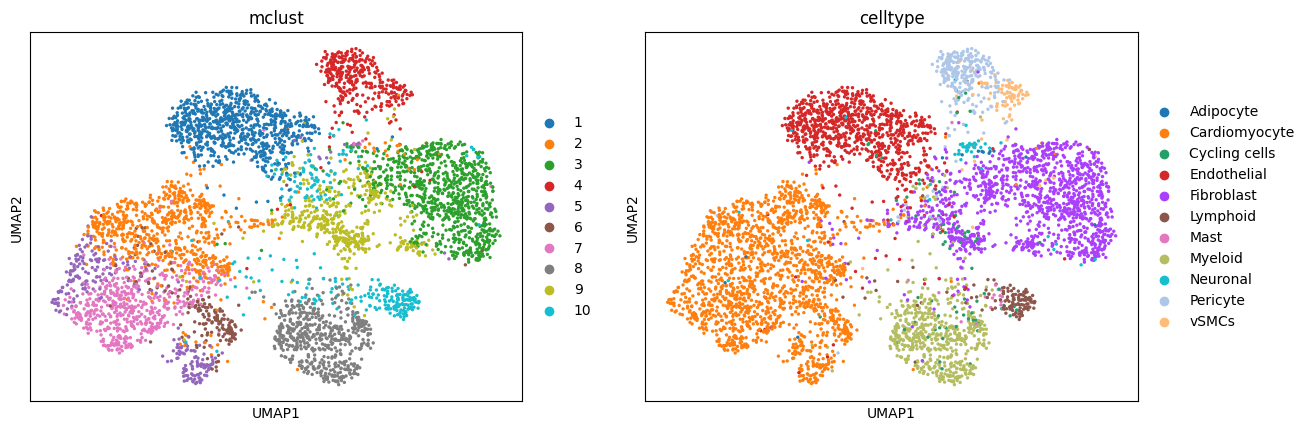

In [ ]:
sc.pp.neighbors(adata_C)
sc.tl.umap(adata_C)
ug.tl.mclust_R(adata_C,10,modelNames='EII')
sc.pl.umap(adata_C, color=["mclust","celltype"])

fitting ...
  |======================================================================| 100%


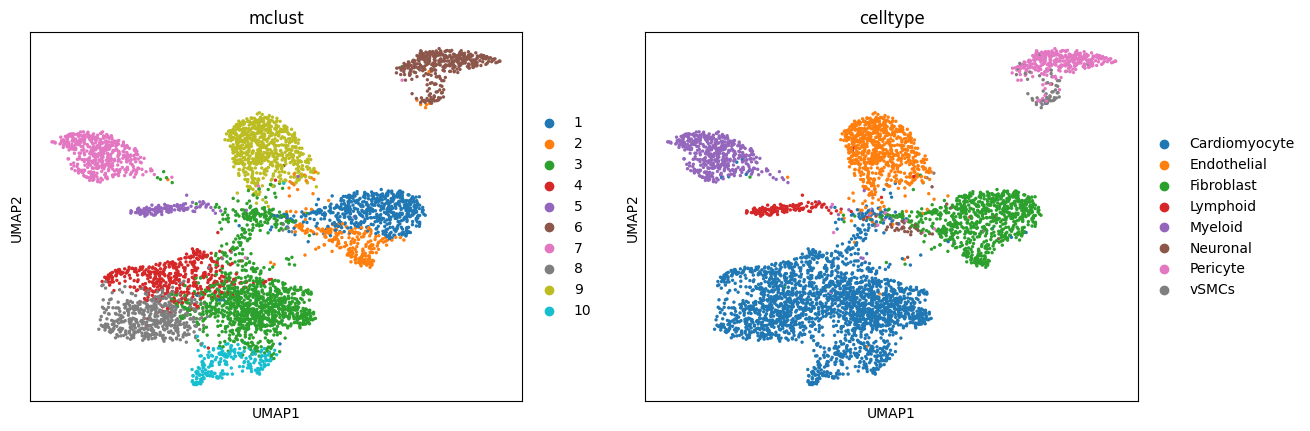

In [ ]:
sc.pp.neighbors(adata_C3)
sc.tl.umap(adata_C3)
ug.tl.mclust_R(adata_C3,10,modelNames='EII')
sc.pl.umap(adata_C3, color=["mclust","celltype"])

fitting ...
  |======================================================================| 100%


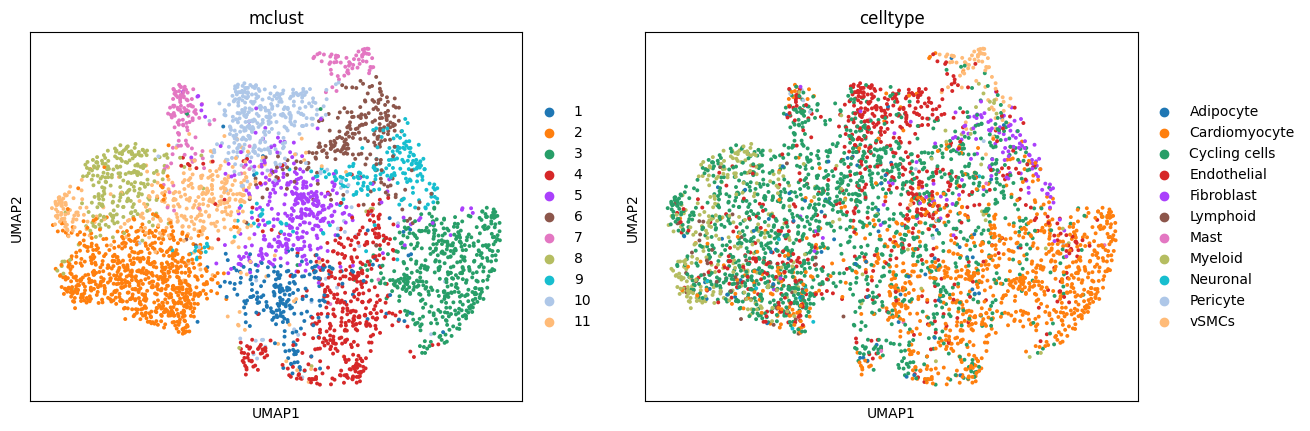

/tmp/ipykernel_421546/2061529470.py:5: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_C2, img_key=None, color=["mclust","celltype"],spot_size = 0.014)


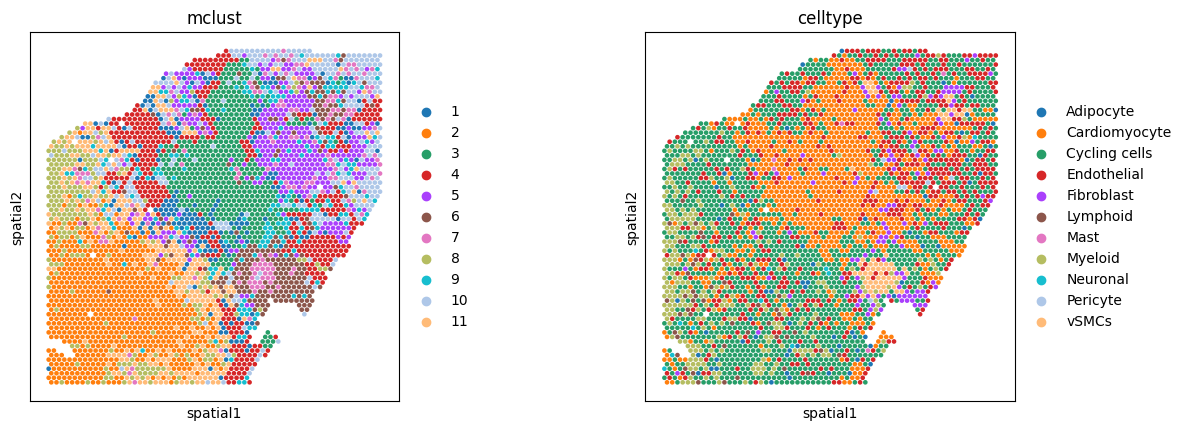

In [ ]:
sc.pp.neighbors(adata_C2)
sc.tl.umap(adata_C2)
ug.tl.mclust_R(adata_C2,11,modelNames='EII')
sc.pl.umap(adata_C2, color=["mclust","celltype"])
sc.pl.spatial(adata_C2, img_key=None, color=["mclust","celltype"],spot_size = 0.014)

Integration of the three embedding spaces

AnnData object with n_obs × n_vars = 13771 × 50
    obs: 'entity_anno', 'celltype', 'mclust', 'batch'
    obsm: 'X_umap'


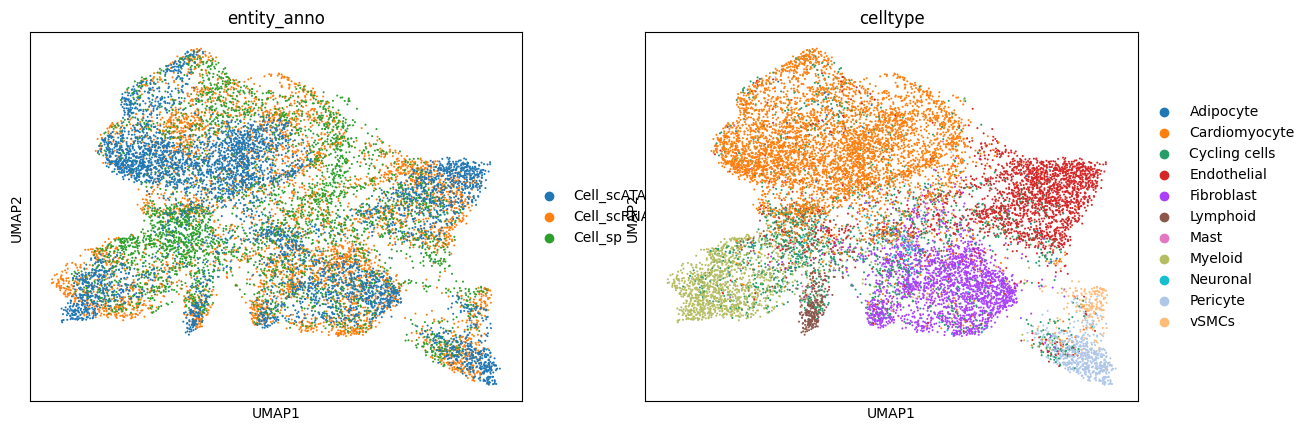

In [ ]:
import anndata as ad
adata_C.obs["batch"] = "scRNA_cells"
adata_C2.obs["batch"] = "sp_spots"
adata_C3.obs["batch"] = "scATAC_cells"
combined = ad.concat([adata_C, adata_C2, adata_C3], label="batch")
print(combined)

sc.pp.neighbors(combined)
sc.tl.umap(combined)
sc.pl.umap(combined, color=["entity_anno","celltype"])

# Spatial assignment for single cells

In [3]:
import pickle
file_path = '/home/nas3/biod/yangchenghui/proj2/proj2_on_HumanHeart/UniG_result/HumanHeart_UniG_adata_dict.pkl'
with open(file_path, 'rb') as f:
    dict_adata = pickle.load(f)
adata_C = dict_adata['C']
adata_C2 = dict_adata['C2']
adata_C3 = dict_adata['C3']
adata_G = dict_adata['G']

map scRNA

In [4]:
adata_sc_mapped_rna,transport,spot_quotas = ug.mapping.map_rna_cells(adata_sc_emb = adata_C, 
                                               adata_st_emb = adata_C2, 
                                               gene_emb = adata_G,
                         label = "celltype", k_cells_per_spot = 5)

Mapping 5000 single cells to 3771 spatial spots.
Step 1: Preparing FGW input matrices.
Step 2: Running Fused Gromov-Wasserstein OT (alpha=0.5).
It.  |Loss        |Relative loss|Absolute loss
------------------------------------------------
    0|3.261498e-01|0.000000e+00|0.000000e+00


/home/yangchenghui/anaconda3/envs/cs_env_new/lib/python3.11/site-packages/ot/lp/__init__.py:388: UserWarning: numItermax reached before optimality. Try to increase numItermax.
  result_code_string = check_result(result_code)


    1|2.064600e-01|5.797240e-01|1.196898e-01
    2|2.064600e-01|0.000000e+00|0.000000e+00
Step 3: Estimating spot-level cell type quotas with NNLS.
Step 4: Assigning cells by OT probability and spot quotas.
Step 5: Assigning remaining cells (15 cells).
Assigned 4985 cells.
Step 6: Computing sub-spot coordinates.
Finished mapping. Output contains 4985 cells.


/tmp/ipykernel_460271/3369790537.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sc_mapped_rna, img_key=None, color=["celltype"],spot_size = 0.014)


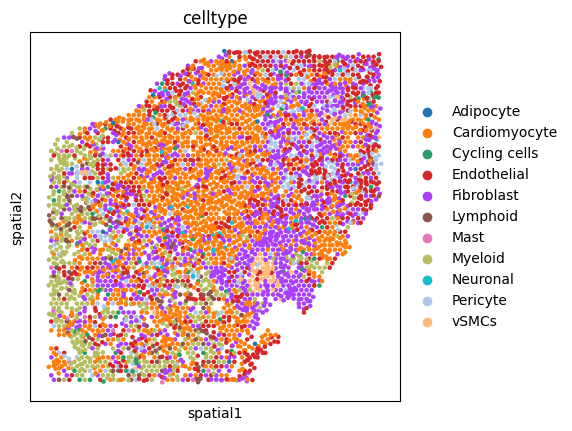

In [5]:
sc.pl.spatial(adata_sc_mapped_rna, img_key=None, color=["celltype"],spot_size = 0.014)

map scATAC

In [6]:
adata_sc_mapped_atac,_ = ug.mapping.map_atac_cells(adata_atac_emb = adata_C3,
                                                 adata_rna_emb = adata_C,
                                                 adata_st_emb = adata_C2,
                                                 pi_spot_rna = transport,
                                                 spot_quotas = spot_quotas,
                        rna_celltype_key="celltype", atac_celltype_key="celltype")

Step 1: Computing cell type-constrained RNA-to-ATAC OT.


Step 2: Composing spot-to-RNA and RNA-to-ATAC transport.
Step 3: Assigning ATAC cells by transport score and spot quotas.
Assigned 4990 ATAC cells.
Step 4: Computing sub-spot coordinates.
Finished mapping. Output contains 4990 ATAC cells.


/tmp/ipykernel_460271/4201443567.py:1: FutureWarning: Use `squidpy.pl.spatial_scatter` instead.
  sc.pl.spatial(adata_sc_mapped_atac, img_key=None, color=["celltype"],spot_size = 0.014)


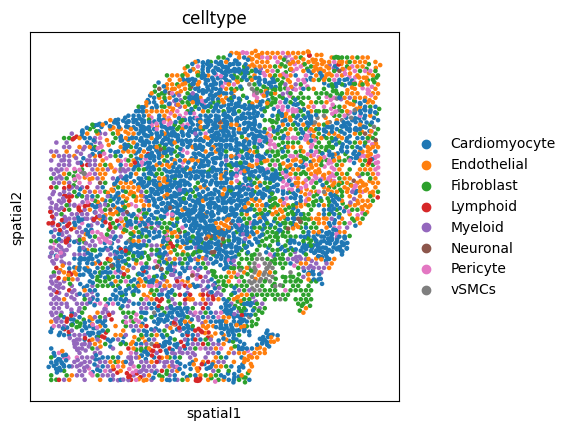

In [7]:
sc.pl.spatial(adata_sc_mapped_atac, img_key=None, color=["celltype"],spot_size = 0.014)